In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/aqi_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (5596714, 22)
Columns: ['country', 'station_id', 'date', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'aqi_PM2.5', 'aqi_PM10', 'aqi_NO2', 'aqi_O3', 'aqi_SO2', 'aqi_CO', 'aqi', 'aqi_category', 'year', 'month', 'day_of_week', 'day_of_year', 'season']


,country,station_id,date,CO,NO2,O3,PM10,PM2.5,SO2,aqi_PM2.5,...,aqi_O3,aqi_SO2,aqi_CO,aqi,aqi_category,year,month,day_of_week,day_of_year,season
0,DE,DE_DEBB007,2013-01-01,NaN,9.789583,56.117917,11.623333,10.125000,NaN,42.187500,...,54.651861,NaN,NaN,54.651861,Moderate,2013,1,1,1,winter
1,DE,DE_DEBB007,2013-01-02,NaN,10.552917,50.872917,8.602083,7.256667,NaN,30.236111,...,47.104552,NaN,NaN,47.104552,Good,2013,1,2,2,winter
2,DE,DE_DEBB007,2013-01-03,NaN,12.682500,35.897917,7.855000,6.994583,NaN,29.144097,...,33.238812,NaN,NaN,33.238812,Good,2013,1,3,3,winter
3,DE,DE_DEBB007,2013-01-04,NaN,15.866667,40.506667,12.782917,10.865000,NaN,45.270833,...,37.506173,NaN,NaN,45.270833,Good,2013,1,4,4,winter
4,DE,DE_DEBB007,2013-01-05,NaN,5.945417,55.106250,4.988333,4.139583,NaN,17.248264,...,51.347083,NaN,NaN,51.347083,Moderate,2013,1,5,5,winter


In [2]:
# Features for the model
# We'll predict AQI using: pollutant values + time features

feature_cols = ["NO2", "O3", "PM10", "PM2.5", "month", "day_of_week", "day_of_year", "year"]

# Drop rows where AQI is missing
df_model = df.dropna(subset=["aqi"]).copy()

# For pollutant columns, fill NaN with -1 (model will learn "no sensor")
for col in ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]:
    df_model[col] = df_model[col].fillna(-1)

# Encode country as numeric
df_model["country_code"] = df_model["country"].astype("category").cat.codes

feature_cols = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2",
                "month", "day_of_week", "day_of_year", "year", "country_code"]

X = df_model[feature_cols]
y_reg = df_model["aqi"]  # regression target
y_cls = df_model["aqi_category"]  # classification target

print(f"Features shape: {X.shape}")
print(f"AQI categories: {y_cls.value_counts().to_dict()}")

Features shape: (5596714, 11)
AQI categories: {'Good': 3065886, 'Moderate': 1584846, 'Unhealthy (Sensitive)': 535940, 'Unhealthy': 209456, 'Hazardous': 162656, 'Very Unhealthy': 37930}


In [3]:
# 5.6M rows is too much for RandomForest — sample 500k for training
# Stratify by category to keep proportions
from sklearn.model_selection import train_test_split

# First: sample 500k rows, stratified by category
df_sample, _ = train_test_split(
    df_model, train_size=500_000, stratify=df_model["aqi_category"], random_state=42
)
print(f"Sample size: {len(df_sample):,}")
print(f"Category distribution preserved:")
print(df_sample["aqi_category"].value_counts(normalize=True).round(3))

# Split into train (80%) and test (20%)
X = df_sample[feature_cols]
y_reg = df_sample["aqi"]
y_cls = df_sample["aqi_category"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Same split indices for classification
y_cls_train = y_cls.loc[X_train.index]
y_cls_test = y_cls.loc[X_test.index]

print(f"\nTrain: {len(X_train):,}  Test: {len(X_test):,}")

Sample size: 500,000
Category distribution preserved:
aqi_category
Good                     0.548
Moderate                 0.283
Unhealthy (Sensitive)    0.096
Unhealthy                0.037
Hazardous                0.029
Very Unhealthy           0.007
Name: proportion, dtype: float64

Train: 400,000  Test: 100,000


In [4]:
# REGRESSION: predict AQI value 
print("Training regression model...")
reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,       # use all CPU cores
    random_state=42,
)
reg_model.fit(X_train, y_reg_train)

y_reg_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)
print(f"MAE: {mae:.2f}")
print(f"R²:  {r2:.4f}")

Training regression model...
MAE: 0.55
R²:  0.9895


too much


In [5]:
# Create lag features: use TODAY's data to predict TOMORROW's AQI
# Sort by station and date first
df_model = df_model.sort_values(["station_id", "date"]).reset_index(drop=True)

# Group by station and shift values by 1 day
pollutant_cols = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2", "aqi"]

for col in pollutant_cols:
    df_model[f"{col}_lag1"] = df_model.groupby("station_id")[col].shift(1)

# Also add 7-day rolling average
for col in ["aqi", "PM2.5", "PM10"]:
    df_model[f"{col}_roll7"] = (
        df_model.groupby("station_id")[col]
        .transform(lambda x: x.shift(1).rolling(7, min_periods=3).mean())
    )

# Drop rows without lag data (first day of each station)
df_lag = df_model.dropna(subset=["aqi_lag1"]).copy()
print(f"Rows with lag features: {len(df_lag):,}")
print(f"\nNew columns: {[c for c in df_lag.columns if 'lag' in c or 'roll' in c]}")

Rows with lag features: 5,594,926

New columns: ['CO_lag1', 'NO2_lag1', 'O3_lag1', 'PM10_lag1', 'PM2.5_lag1', 'SO2_lag1', 'aqi_lag1', 'aqi_roll7', 'PM2.5_roll7', 'PM10_roll7']


In [6]:
# Real features: yesterday's data to predict today's AQI
lag_features = [
    "CO_lag1", "NO2_lag1", "O3_lag1", "PM10_lag1", "PM2.5_lag1", "SO2_lag1",
    "aqi_lag1", "aqi_roll7", "PM2.5_roll7", "PM10_roll7",
    "month", "day_of_week", "day_of_year", "country_code",
]

# Fill NaN in lag pollutant columns
for col in lag_features:
    df_lag[col] = df_lag[col].fillna(-1)

# Sample again
df_sample2, _ = train_test_split(
    df_lag, train_size=500_000, stratify=df_lag["aqi_category"], random_state=42
)

X = df_sample2[lag_features]
y_reg = df_sample2["aqi"]
y_cls = df_sample2["aqi_category"]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
y_cls_train = y_cls.loc[X_train.index]
y_cls_test = y_cls.loc[X_test.index]

# Train regression
print("Training regression model (lag features)...")
reg_model = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
reg_model.fit(X_train, y_reg_train)

y_reg_pred = reg_model.predict(X_test)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)
print(f"MAE: {mae:.2f}")
print(f"R²:  {r2:.4f}")

Training regression model (lag features)...
MAE: 29.79
R²:  0.2603


let's try XGBoost

In [7]:
from xgboost import XGBRegressor, XGBClassifier

# XGBoost regression
print("Training XGBoost regression...")
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)
xgb_reg.fit(X_train, y_reg_train)

y_xgb_pred = xgb_reg.predict(X_test)
mae_xgb = mean_absolute_error(y_reg_test, y_xgb_pred)
r2_xgb = r2_score(y_reg_test, y_xgb_pred)

print(f"\nRandom Forest — MAE: {mae:.2f}, R²: {r2:.4f}")
print(f"XGBoost       — MAE: {mae_xgb:.2f}, R²: {r2_xgb:.4f}")

Training XGBoost regression...

Random Forest — MAE: 29.79, R²: 0.2603
XGBoost       — MAE: 30.61, R²: 0.2451


Training XGBoost classifier...

Classification Report:
                       precision    recall  f1-score   support

                 Good       0.84      0.87      0.86     54749
            Hazardous       0.57      0.00      0.00      2841
             Moderate       0.59      0.64      0.61     28413
            Unhealthy       0.48      0.44      0.46      3700
Unhealthy (Sensitive)       0.47      0.43      0.45      9626
       Very Unhealthy       0.57      0.38      0.46       671

             accuracy                           0.72    100000
            macro avg       0.59      0.46      0.47    100000
         weighted avg       0.71      0.72      0.71    100000



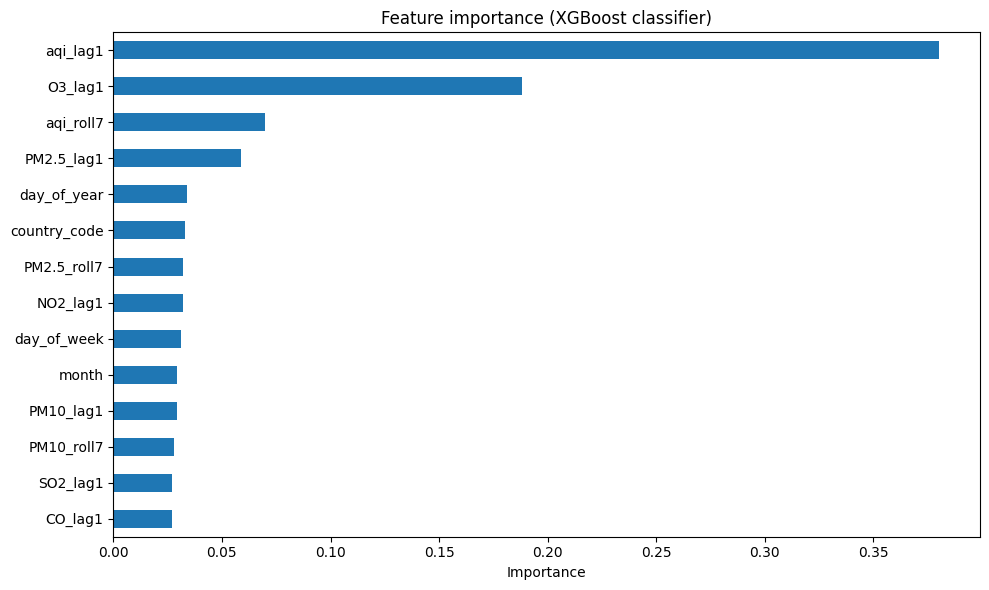

In [9]:
# CLASSIFICATION: predict AQI category
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_cls_train_enc = le.fit_transform(y_cls_train)
y_cls_test_enc = le.transform(y_cls_test)

print("Training XGBoost classifier...")
xgb_cls = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)
xgb_cls.fit(X_train, y_cls_train_enc)

y_cls_pred_enc = xgb_cls.predict(X_test)
y_cls_pred = le.inverse_transform(y_cls_pred_enc)

print("\nClassification Report:")
print(classification_report(y_cls_test, y_cls_pred))

# Feature importance
importance = pd.Series(
    xgb_cls.feature_importances_, index=lag_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax)
ax.set_title("Feature importance (XGBoost classifier)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
import joblib

# Save both models
joblib.dump(xgb_reg, "../models/xgb_regressor.joblib")
joblib.dump(xgb_cls, "../models/xgb_classifier.joblib")
joblib.dump(le, "../models/label_encoder.joblib")

# Save feature list for backend
import json
with open("../models/feature_config.json", "w") as f:
    json.dump({"features": lag_features}, f, indent=2)

print("Models saved to models/")
print(f"Regression  — MAE: {mae_xgb:.2f}, R²: {r2_xgb:.4f}")
print(f"Classifier  — Accuracy: 0.72, F1 (weighted): 0.71")

Models saved to models/
Regression  — MAE: 30.61, R²: 0.2451
Classifier  — Accuracy: 0.72, F1 (weighted): 0.71
